In [1]:
!pip install lightgbm imbalanced-learn shap

In [3]:
import pandas as pd

df = pd.read_csv("/content/cleaned_indian_startups.csv")

print("Shape:", df.shape)
print(df.columns)
df.head()

Shape: (371, 37)
Index(['startup_name', 'industry', 'sub_industry', 'city', 'state',
       'year_founded', 'company_age', 'total_funding_usd_mn',
       'valuation_usd_mn', 'revenue_usd_mn', 'employees', 'funding_rounds',
       'seed_usd_mn', 'series_a_usd_mn', 'series_b_usd_mn',
       'time_between_rounds_months', 'last_funding_year', 'founder_names',
       'num_founders', 'founder_exp_yrs', 'prev_startups', 'tech_founder',
       'education_level', 'website_traffic_mn_monthly', 'app_downloads_mn',
       'social_media_followers_mn', 'market_size_usd_bn', 'competitor_count',
       'market_growth_rate_pct', 'profit_loss_usd_mn',
       'burn_rate_usd_mn_monthly', 'growth_rate_pct', 'is_unicorn',
       'ipo_status', 'investment_score_0_100', 'investment_recommendation',
       'data_verified'],
      dtype='object')


,startup_name,industry,sub_industry,city,state,year_founded,company_age,total_funding_usd_mn,valuation_usd_mn,revenue_usd_mn,...,competitor_count,market_growth_rate_pct,profit_loss_usd_mn,burn_rate_usd_mn_monthly,growth_rate_pct,is_unicorn,ipo_status,investment_score_0_100,investment_recommendation,data_verified
0,Paytm,Fintech,Payments,Noida,UP,2010,15,3820.0,6000.0,410.0,...,18,32.0,-180.0,42.0,14.0,1,Listed,48.0,Invest,Verified
1,PhonePe,Fintech,UPI Payments,Bengaluru,KA,2015,10,850.0,12000.0,44.6,...,15,35.0,-90.0,30.0,40.0,1,Private,30.8,Hold,Verified
2,Razorpay,Fintech,Payment Gateway,Bengaluru,KA,2014,11,741.0,7500.0,44.6,...,14,28.0,-45.0,18.0,55.0,1,Private,30.1,Hold,Verified
3,CRED,Fintech,Credit Rewards,Bengaluru,KA,2018,7,869.0,6400.0,44.6,...,20,45.0,-110.0,25.0,30.0,1,Private,27.2,Avoid,Verified
4,BharatPe,Fintech,Merchant Payments,New Delhi,DL,2018,7,624.0,2850.0,44.6,...,22,38.0,-60.0,15.0,25.0,1,Private,26.2,Avoid,Verified


In [17]:
df = df.drop([
    "startup_name",
    "founder_names"
], axis=1, errors='ignore')

In [18]:
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_4107/3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [19]:
df = pd.get_dummies(df, drop_first=True)

In [32]:
TARGET = "investment_recommendation_Invest"

X = df.drop([
    "investment_recommendation_Invest",
    "investment_recommendation_Hold",
     "investment_score_0_100" # 🔥 REMOVE LEAKAGE
], axis=1)

y = df[TARGET]

In [33]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X, y = smote.fit_resample(X, y)

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [35]:
feature_names = X.columns

from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold(threshold=0.01)

X_train = selector.fit_transform(X_train)
X_test = selector.transform(X_test)

# Restore selected feature names
selected_features = feature_names[selector.get_support()]

In [36]:
from lightgbm import LGBMClassifier

model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    min_child_samples=20
)

model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 292, number of negative: 277
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000470 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3315
[LightGBM] [Info] Number of data points in the train set: 569, number of used features: 71
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.513181 -> initscore=0.052736
[LightGBM] [Info] Start training from score 0.052736
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


LGBMClassifier(learning_rate=0.05, max_depth=4, n_estimators=200)

In [37]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.993006993006993

Classification Report:
               precision    recall  f1-score   support

       False       1.00      0.99      0.99        79
        True       0.98      1.00      0.99        64

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


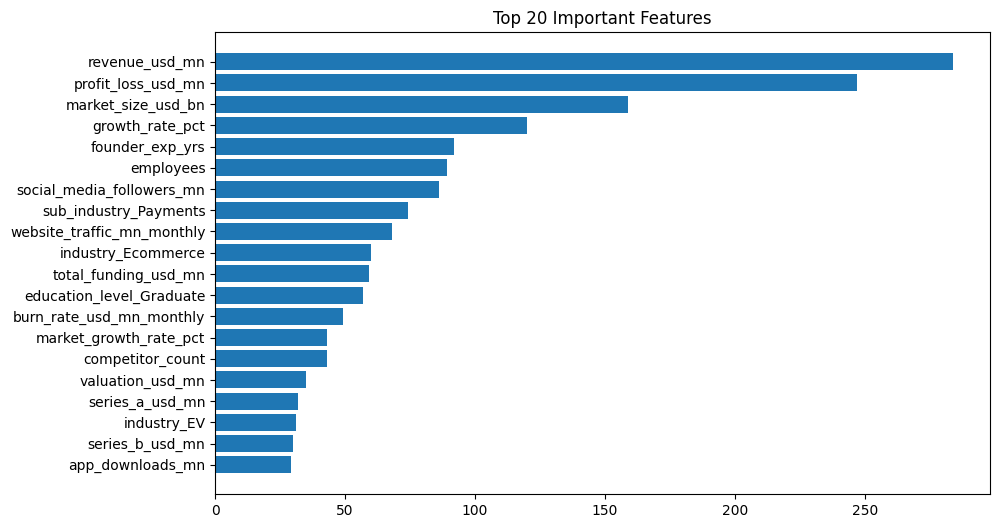

In [38]:
import matplotlib.pyplot as plt
import numpy as np

importances = model.feature_importances_

# Get selected feature names
# Save feature names BEFORE split
feature_names = X.columns

# After VarianceThreshold
selected_features = feature_names[selector.get_support()]

# Top 20 features only (clean visualization)
indices = np.argsort(importances)[-20:]

plt.figure(figsize=(10,6))
plt.barh(selected_features[indices], importances[indices])
plt.title("Top 20 Important Features")
plt.show()

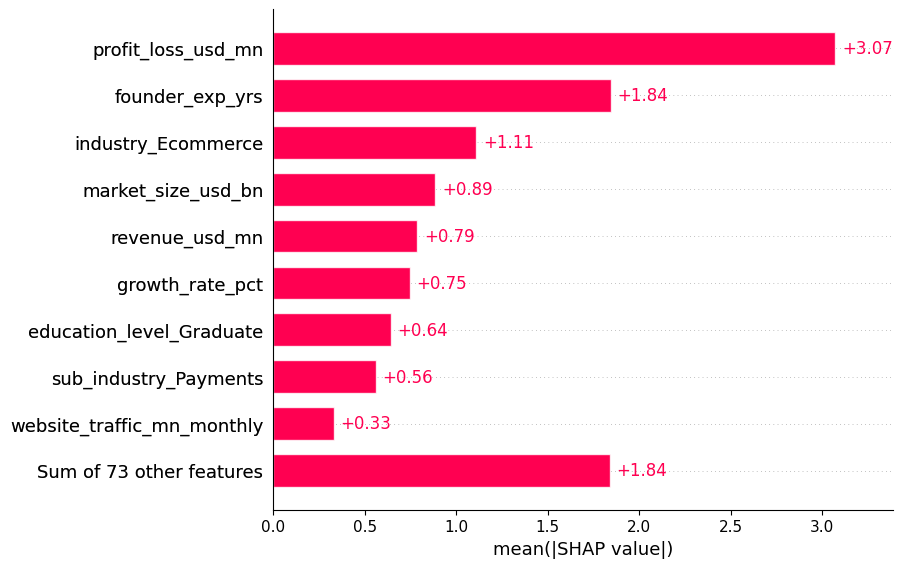

In [39]:
import pandas as pd
import shap

# Convert back to DataFrame
X_test_df = pd.DataFrame(X_test, columns=selected_features)

explainer = shap.Explainer(model)
shap_values = explainer(X_test_df)

shap.plots.bar(shap_values)

In [40]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [200, 300],
    'learning_rate': [0.01, 0.05],
    'max_depth': [4, 6]
}

grid = GridSearchCV(LGBMClassifier(), params, cv=3, n_jobs=-1)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

[LightGBM] [Info] Number of positive: 292, number of negative: 277
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000474 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3315
[LightGBM] [Info] Number of data points in the train set: 569, number of used features: 71
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.513181 -> initscore=0.052736
[LightGBM] [Info] Start training from score 0.052736
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [41]:
import joblib

joblib.dump(model, "startup_model.pkl")
joblib.dump(selector, "feature_selector.pkl")
joblib.dump(selected_features, "feature_names.pkl")

['feature_names.pkl']